In [4]:
import pathlib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

import paint.util.paint_mappings as mappings
from paint.data.dataset import PaintCalibrationDataset
from paint.util import set_logger_config

# Setup logging
set_logger_config()

print("Imports complete!")

Imports complete!


In [5]:
# Dataset configuration
BENCHMARK_NAME = "benchmark_split-balanced_train-10_validation-30"
BASE_DIR = pathlib.Path("..") / pathlib.Path.cwd() / "paint_benchmarks"

# Item types to load
ITEM_TYPES = [
    mappings.CALIBRATION_PROPERTIES_KEY,  # "calibration_properties"
    mappings.CALIBRATION_FLUX_IMAGE_KEY,  # "flux_image"
]

# Training configuration
BATCH_SIZE = 32
NUM_WORKERS = 4
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Base directory: {BASE_DIR}")
print(f"Benchmark: {BENCHMARK_NAME}")
print(f"Device: {DEVICE}")

Base directory: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks
Benchmark: benchmark_split-balanced_train-10_validation-30
Device: cpu


In [6]:
# Get benchmark file path
benchmark_file = BASE_DIR / "splits" / f"{BENCHMARK_NAME}.csv"

print(f"Loading datasets from: {benchmark_file}")
print()

# Dictionary to store all datasets
datasets = {}

# Load datasets for each item type
for item_type in ITEM_TYPES:
    print(f"Loading {item_type} datasets...")
    
    # Dataset directory for this item type
    dataset_dir = BASE_DIR / "datasets" / BENCHMARK_NAME / item_type
    
    # Load datasets (download=False since data is already organized)
    train_dataset, test_dataset, val_dataset = PaintCalibrationDataset.from_benchmark(
        benchmark_file=benchmark_file,
        root_dir=dataset_dir,
        item_type=item_type,
        download=False,  # Data already downloaded
    )
    
    datasets[item_type] = {
        'train': train_dataset,
        'test': test_dataset,
        'val': val_dataset,
    }
    
    print(f"  ✓ Train: {len(train_dataset)} samples")
    print(f"  ✓ Test:  {len(test_dataset)} samples")
    print(f"  ✓ Val:   {len(val_dataset)} samples")
    print()

print(f"Successfully loaded {len(datasets)} dataset types!")

Loading datasets from: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/splits/benchmark_split-balanced_train-10_validation-30.csv

Loading calibration_properties datasets...
[2026-01-21 17:51:59,352][paint.data.dataset][INFO] - Begining the process of generating benchmark datasets. The file used to generate the benchmarks is:
 /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/splits/benchmark_split-balanced_train-10_validation-30.csv!
[2026-01-21 17:51:59,352][paint.data.dataset][INFO] - Begining the process of generating benchmark datasets. The file used to generate the benchmarks is:
 /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/splits/benchmark_split-balanced_train-10_validation-30.csv!
[2026-01-21 17:51:59,369][paint.data.dataset][INFO] - Initializing a data set for calibration_properties calibration items...
[2026-01-21 17:51:59,369][paint.data.dataset][INFO] - Initializing a data set for calibration_properties calibration ite

In [7]:
# Inspect a sample from each dataset
for item_type in ITEM_TYPES:
    print("=" * 80)
    print(f"Inspecting {item_type} - Training set - Sample 0")
    print("=" * 80)
    
    sample = datasets[item_type]['train'][0]
    
    print(f"Sample type: {type(sample)}")
    
    if isinstance(sample, dict):
        print(f"Keys: {list(sample.keys())}")
        print("\nContent:")
        for key, value in sample.items():
            if isinstance(value, torch.Tensor):
                print(f"  {key}: Tensor shape={value.shape}, dtype={value.dtype}")
            elif isinstance(value, dict):
                print(f"  {key}: Dict with keys={list(value.keys())}")
                # Print nested dict details
                for k2, v2 in value.items():
                    print(f"    - {k2}: {v2 if not isinstance(v2, (list, dict)) else type(v2)}")
            else:
                print(f"  {key}: {value}")
    elif isinstance(sample, torch.Tensor):
        print(f"Tensor shape: {sample.shape}")
        print(f"Tensor dtype: {sample.dtype}")
        print(f"Min value: {sample.min().item():.4f}")
        print(f"Max value: {sample.max().item():.4f}")
        print(f"Mean value: {sample.mean().item():.4f}")
    
    print()

Inspecting calibration_properties - Training set - Sample 0
Sample type: <class 'dict'>
Keys: ['motor_position', 'target_name', 'sun_elevation', 'sun_azimuth', 'focal_spot']

Content:
  motor_position: Dict with keys=['axis_1_motor_position', 'axis_2_motor_position']
    - axis_1_motor_position: 33435
    - axis_2_motor_position: 67122
  target_name: solar_tower_juelich_upper
  sun_elevation: 55.46259850075815
  sun_azimuth: -38.78968202949045
  focal_spot: Dict with keys=['HeliOS', 'UTIS']
    - HeliOS: <class 'list'>
    - UTIS: <class 'list'>

Inspecting flux_image - Training set - Sample 0
Sample type: <class 'torch.Tensor'>
Tensor shape: torch.Size([3, 256, 256])
Tensor dtype: torch.float32
Min value: 0.0000
Max value: 1.0000
Mean value: 0.0569



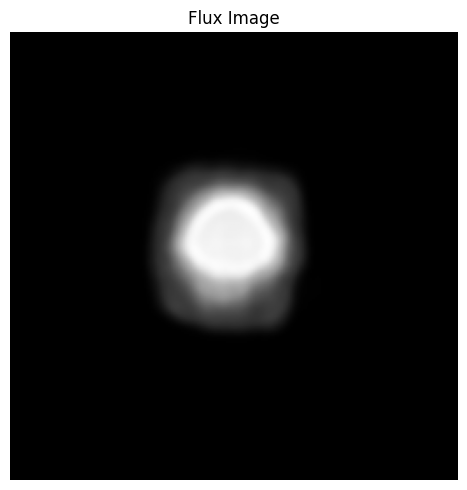

Image shape: (3, 256, 256)
Image range: [0.0000, 1.0000]


In [14]:
# Visualize a flux image if available
if 'flux_image' in datasets:
    sample_image = datasets['flux_image']['train'][0]
    
    if isinstance(sample_image, torch.Tensor):
        # Convert to numpy for visualization
        img = sample_image.numpy()
        
        # Create figure
        fig, axes = plt.subplots(1, 1, figsize=(15, 5))
        
        axes.imshow(img[0], cmap='gray')
        axes.set_title('Flux Image')
        axes.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Image shape: {img.shape}")
        print(f"Image range: [{img.min():.4f}, {img.max():.4f}]")

In [9]:
print("Creating DataLoaders...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Num workers: {NUM_WORKERS}")
print()

dataloaders = {}

for item_type in ITEM_TYPES:
    print(f"Creating dataloaders for {item_type}...")
    
    train_loader = DataLoader(
        datasets[item_type]['train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    
    test_loader = DataLoader(
        datasets[item_type]['test'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    
    val_loader = DataLoader(
        datasets[item_type]['val'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    
    dataloaders[item_type] = {
        'train': train_loader,
        'test': test_loader,
        'val': val_loader,
    }
    
    print(f"  ✓ Train batches: {len(train_loader)}")
    print(f"  ✓ Test batches:  {len(test_loader)}")
    print(f"  ✓ Val batches:   {len(val_loader)}")
    print()

print("DataLoaders created!")

Creating DataLoaders...
Batch size: 32
Num workers: 4

Creating dataloaders for calibration_properties...
  ✓ Train batches: 411
  ✓ Test batches:  1233
  ✓ Val batches:   1233

Creating dataloaders for flux_image...
  ✓ Train batches: 409
  ✓ Test batches:  1225
  ✓ Val batches:   1225

DataLoaders created!


In [15]:
# Test iterating through dataloaders
print("Testing DataLoaders - First Batch:")
print()

for item_type in ITEM_TYPES:
    print(f"{item_type}:")
    train_loader = dataloaders[item_type]['train']
    
    # Get first batch
    batch = next(iter(train_loader))
    
    if isinstance(batch, torch.Tensor):
        print(f"  Batch shape: {batch.shape}")
        print(f"  Batch dtype: {batch.dtype}")
        print(f"  Batch device: {batch.device}")
    elif isinstance(batch, dict):
        print(f"  Batch is a dictionary with keys: {list(batch.keys())}")
        for key, value in batch.items():
            if isinstance(value, torch.Tensor):
                print(f"    {key}: shape={value.shape}, dtype={value.dtype}")
            elif isinstance(value, dict):
                print(f"    {key}: nested dict with keys={list(value.keys())}")
    print()

Testing DataLoaders - First Batch:

calibration_properties:
  Batch is a dictionary with keys: ['motor_position', 'target_name', 'sun_elevation', 'sun_azimuth', 'focal_spot']
    motor_position: nested dict with keys=['axis_1_motor_position', 'axis_2_motor_position']
    sun_elevation: shape=torch.Size([32]), dtype=torch.float64
    sun_azimuth: shape=torch.Size([32]), dtype=torch.float64
    focal_spot: nested dict with keys=['HeliOS', 'UTIS']

flux_image:
  Batch shape: torch.Size([32, 3, 256, 256])
  Batch dtype: torch.float32
  Batch device: cpu



{'calibration_properties': {'train': <paint.data.dataset.PaintCalibrationDataset object at 0x1068d3b20>, 'test': <paint.data.dataset.PaintCalibrationDataset object at 0x106a161a0>, 'val': <paint.data.dataset.PaintCalibrationDataset object at 0x106a162c0>}, 'flux_image': {'train': <paint.data.dataset.PaintCalibrationDataset object at 0x106a14070>, 'test': <paint.data.dataset.PaintCalibrationDataset object at 0x106a16f20>, 'val': <paint.data.dataset.PaintCalibrationDataset object at 0x106a16080>}}
